Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
from pathlib import Path

plt.rcParams["figure.constrained_layout.use"] = True

## Visualisation

In [2]:
weighted_update_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "weighted_update_summary.csv"
)
weighted_update_df = weighted_update_df[weighted_update_df.session == 2]

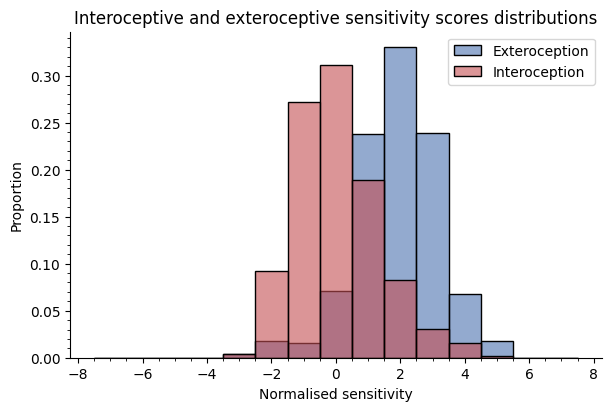

In [3]:
_, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    weighted_update_df.logit_exteroceptive_sensitivity.to_numpy(),
    color="#4c72b0",
    alpha=0.6,
    stat="proportion",
    binwidth=1,
    binrange=(-7.5, 7.5),
    label="Exteroception",
    ax=ax,
)

sns.histplot(
    weighted_update_df.logit_interoceptive_sensitivity.to_numpy(),
    color="#c44e52",
    alpha=0.6,
    stat="proportion",
    binwidth=1,
    binrange=(-7.5, 7.5),
    label="Interoception",
    ax=ax,
)
ax.set(
    title="Interoceptive and exteroceptive sensitivity scores distributions",
    xlabel="Normalised sensitivity",
)
ax.legend()
ax.minorticks_on()
sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_3_intero_extero.svg")

In [4]:
weighted_update_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "weighted_update_summary.csv"
)
merged = pd.merge(
    weighted_update_df[weighted_update_df.session == 1],
    weighted_update_df[weighted_update_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

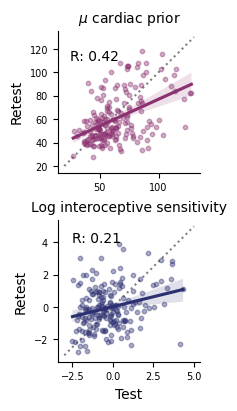

In [7]:
fig, axs = plt.subplots(figsize=(2, 4), nrows=2)

merged = pd.merge(
    weighted_update_df[weighted_update_df.session == 1],
    weighted_update_df[weighted_update_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

sns.regplot(
    x=merged["mu_cardiac_prior_del1"],
    y=merged["mu_cardiac_prior_del2"],
    scatter_kws={"s": 10, "alpha": .4},
    color="#8b3170",
    ax=axs[0]
)
axs[0].annotate(
    f"R: {round(pg.corr(
    x=merged["mu_cardiac_prior_del1"].to_numpy(),
    y=merged["mu_cardiac_prior_del2"].to_numpy(),
    method="spearman",
).r.iloc[0], 2)}",
    (25, 110)
)

sns.regplot(
    x=merged["logit_interoceptive_sensitivity_del1"],
    y=merged["logit_interoceptive_sensitivity_del2"],
    color="#2c3071",
    scatter_kws={"s": 10, "alpha": .4},
    ax=axs[1]
)
axs[1].annotate(
    f"R: {round(pg.corr(
    x=merged["logit_interoceptive_sensitivity_del1"].to_numpy(),
    y=merged["logit_interoceptive_sensitivity_del2"].to_numpy(),
    method="spearman",
).r.iloc[0], 2)}",
    (-2.5, 4)
)

axs[0].plot((20, 130), (20, 130), linestyle=":", color="gray", zorder=0)
axs[0].tick_params(axis='both', labelsize=7)
axs[0].set_title(r"$\mu$ cardiac prior", fontsize=10)
axs[1].plot((-3, 5), (-3,5), linestyle=":", color="gray", zorder=0)
axs[1].tick_params(axis='both', labelsize=7)
axs[1].set_title("Log interoceptive sensitivity", fontsize=10)

axs[0].set(xlabel=None, ylabel="Retest")
axs[1].set(xlabel="Test", ylabel="Retest")

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_3_reliability.svg")